## **ASSIGNMENT 2**: Linear regression on the Iris dataset

In [26]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import random
from sklearn.datasets import load_iris

In [27]:
# load Iris dataset
iris = load_iris()
type(iris)

sklearn.utils._bunch.Bunch

In [28]:
# print the names of the features
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [29]:
# print the Iris target
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [30]:
# print the Iris target name
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [31]:
# store Iris data in X
X = iris.data

# store Iris target in y
y = iris.target

In [32]:
# turning it into a DataFrame
df = pd.DataFrame(X, columns=iris.feature_names)
df["species"] = y

In [33]:
# inspect the dataframe
df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


### **Selecting the features**
I selected 3 pairs of variables from the 4 features of the Iris dataset:
1. independent variable: **sepal length** & dependent variable: **sepal width**;
2. independent variable: **petal length** & dependent variable: **petal width**;
3. independent variable: **petal width** & dependent variable: **sepal length**;

In [34]:
def calculate_mse(X, Y, w, b):
    m = len(X)
    total_error = 0
    for i in range(m):
        Y_pred = w * X[i] + b
        total_error += (Y[i] - Y_pred) ** 2
    return total_error / m


def plot_regression_line(X, Y, w, b, title="Regression Line"):
    plt.scatter(X, Y, color="blue")

    x_line = X
    y_line = w * x_line + b

    plt.plot(x_line, y_line, color="red", label=f"y = {w:.2f}x + {b:.2f}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(title)
    plt.legend()
    plt.show()


def random_search(X, Y, iterations, step_size):
    b = random.uniform(-1, 1)
    w = random.uniform(-1, 1)
    best_MSE = calculate_mse(X, Y, w, b)
    best_b, best_w = b, w

    for i in range(iterations):
        new_w = best_w + random.uniform(-step_size, step_size)
        new_b = best_b + random.uniform(-step_size, step_size)  

        MSE = calculate_mse(X, Y, new_w, new_b)

        if MSE < best_MSE:
            best_MSE, best_w, best_b = MSE, new_w, new_b

    print(f"Random Search: Best MSE = {best_MSE}, b = {best_b}, w = {best_w}")
    return best_w, best_b, best_MSE


def gradient_descent(X, Y, learning_rate, iterations):
    b = random.uniform(-1, 1)
    w = random.uniform(-1, 1)
    m = len(X)

    for i in range(iterations):
        db = -2/m * sum((Y[j] - (w*X[j] + b)) for j in range(m))
        dw = -2/m * sum((Y[j] - (w*X[j] + b)) * X[j] for j in range(m))

        b -= learning_rate * db
        w -= learning_rate * dw

    MSE = calculate_mse(X, Y, w, b)

    print(f"Gradient Descent: Best MSE = {MSE}, b = {b}, w = {w}")
    return w, b, MSE


def linear_regression(X, Y, method, learning_rate=0.01, iterations=10, step_size=0.01):
    if method == "random":
        return random_search(X, Y, iterations, step_size)
    elif method == "gradient":
        return gradient_descent(X, Y, learning_rate, iterations)
    else:
        raise ValueError("Unknown method. Use 'random' or 'gradient'.")


---

* #### **Pair 1**: Sepal Length vs. Sepal Width

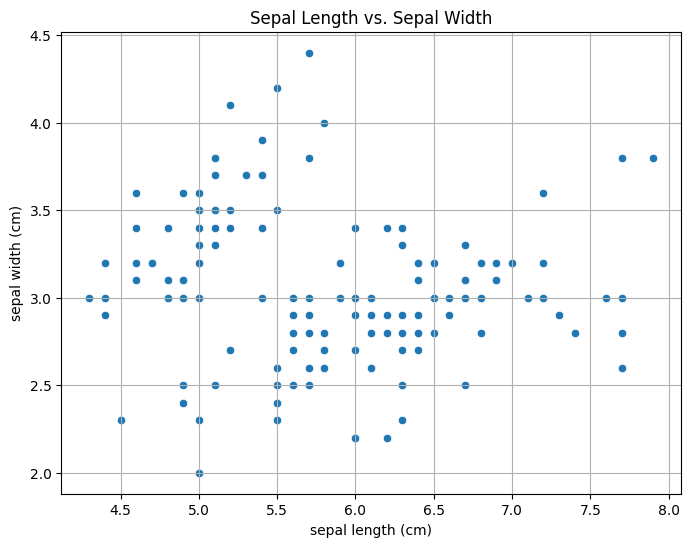

In [35]:
# scatter plot for pair 1
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="sepal length (cm)", y="sepal width (cm)")
plt.title("Sepal Length vs. Sepal Width")
plt.grid(True)
plt.show()


In [36]:
X1 = df["sepal length (cm)"].values
Y1 = df["sepal width (cm)"].values

Random Search: Best MSE = 0.22098546814882014, b = 2.1078009816474874, w = 0.16412198504051428


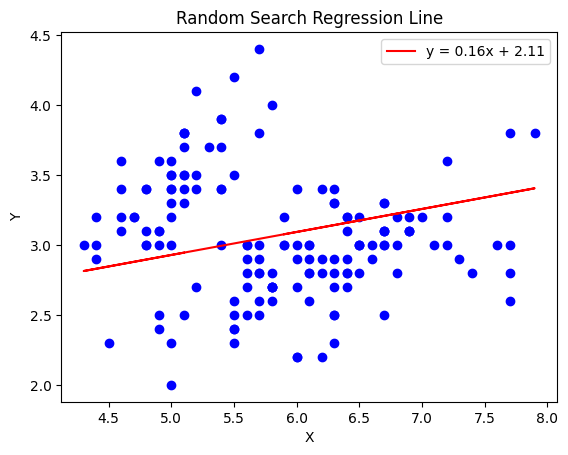

In [37]:
w1, b1, mse1 = linear_regression(X1, Y1, "random", iterations=500, step_size=0.1)
plot_regression_line(X1, Y1, w1, b1, "Random Search Regression Line")

Gradient Descent: Best MSE = 0.3944281101222374, b = 0.1552987810397751, w = 0.48601586229820065


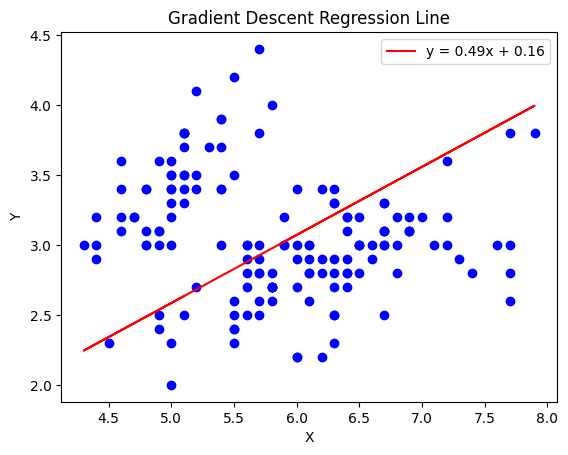

In [38]:
w1, b1, mse1 = linear_regression(X1, Y1, "gradient", 0.01, 500)
plot_regression_line(X1, Y1, w1, b1, "Gradient Descent Regression Line")

---

* #### **Pair 2**: Petal Length vs. Petal Width

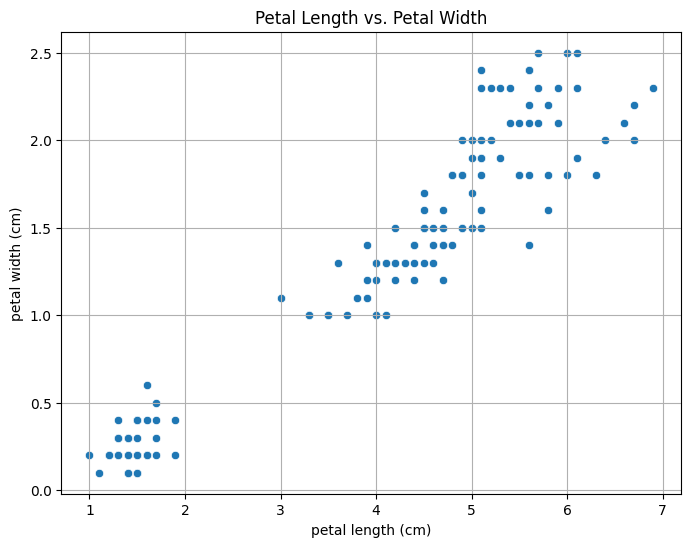

In [39]:
# scatter plot for pair 2
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="petal length (cm)", y="petal width (cm)")
plt.title("Petal Length vs. Petal Width")
plt.grid(True)
plt.show()

In [40]:
X2 = df["petal length (cm)"].values
Y2 = df["petal width (cm)"].values

Random Search: Best MSE = 0.04207937484719621, b = -0.35544807027133946, w = 0.4143960902885895


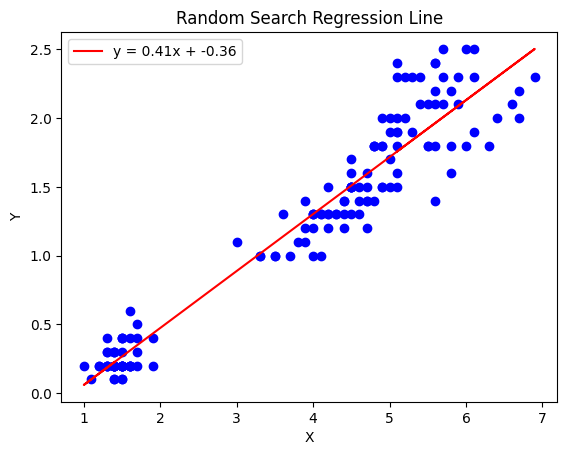

In [41]:
w2, b2, mse2 = linear_regression(X2, Y2, "random", iterations=500, step_size=0.1)
plot_regression_line(X2, Y2, w2, b2, "Random Search Regression Line")

Gradient Descent: Best MSE = 0.04549875834137908, b = -0.22495280861746206, w = 0.3853055290346373


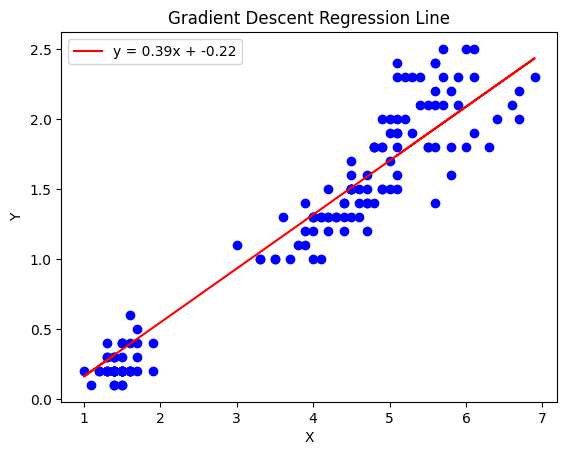

In [42]:
w2, b2, mse2 = linear_regression(X2, Y2, "gradient", 0.01, 600)
plot_regression_line(X2, Y2, w2, b2, "Gradient Descent Regression Line")

---

* #### **Pair 3**: Petal Width vs. Sepal Length

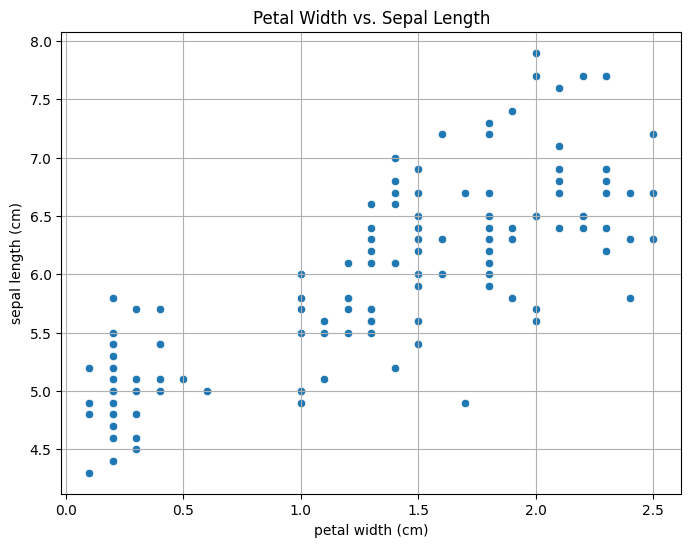

In [43]:
# scatter plot for pair 3
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="petal width (cm)", y="sepal length (cm)")
plt.title("Petal Width vs. Sepal Length")
plt.grid(True)
plt.show()

In [44]:
X3 = df["petal width (cm)"].values
Y3 = df["sepal length (cm)"].values

Random Search: Best MSE = 0.22544016093855315, b = 4.782603307454469, w = 0.8851330834489283


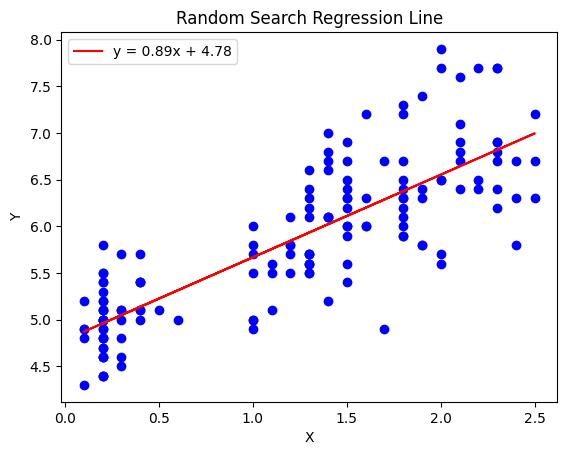

In [45]:
w3, b3, mse3 = linear_regression(X3, Y3, "random", iterations=500, step_size=0.1)
plot_regression_line(X3, Y3, w3, b3, "Random Search Regression Line")

Gradient Descent: Best MSE = 0.2261059178796216, b = 4.729897294992083, w = 0.9202054885941255


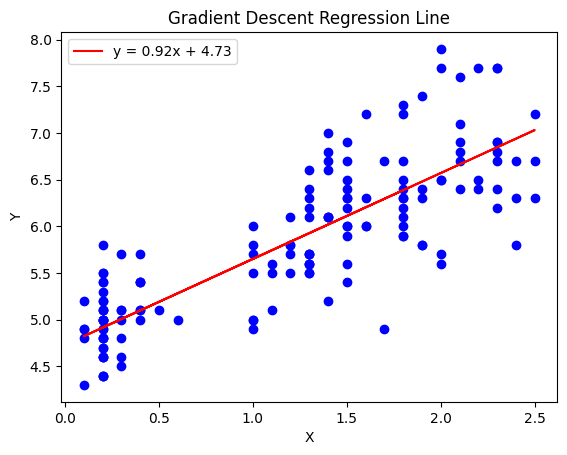

In [46]:
w3, b3, mse3 = linear_regression(X3, Y3, "gradient", 0.02, 500)
plot_regression_line(X3, Y3, w3, b3, "Gradient Descent Regression Line")